# 🩺 Model Monitoring & Drift Detection (Evidently AI)

Models decay over time because data changes 📉. **Evidently AI** compares training data vs production data to detect drift and tell us when it's time to retrain.

**In this notebook, we will:**
1. 📊 Prepare reference (training) and current (production) datasets
2. 🧪 Simulate data drift to see Evidently in action
3. 📋 Generate an interactive drift report
4. 🎯 Decide: retrain or keep serving?

In [1]:
# Loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

try:
    from IPython.display import display
except ImportError:
    def display(obj): print(obj)

# Load pre-processed data
processed_dir = pathlib.Path.cwd().parent / 'data' / 'processed'
df = pd.read_csv(processed_dir / 'online_retail_initial.csv', parse_dates=['InvoiceDate'])

# RFM feature engineering
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
features = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()
features.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Target: high-value customers (above median spend)
features['target'] = (features['Monetary'] > features['Monetary'].median()).astype(int)

# Train/test split
X = features[['Recency', 'Frequency', 'Monetary']]
y = features['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Reference data: {len(X_train):,} rows | Current data: {len(X_test):,} rows")

✅ Reference data: 4,753 rows | Current data: 1,189 rows


In [2]:
import os
import json
from evidently import Report
from evidently.presets import DataDriftPreset

## 2. Prepare Reference & Current Data

reference = X_train.copy()
reference['target'] = y_train

current = X_test.copy()
current['target'] = y_test

# 🧪 Simulate drift: increase Recency by 50%
current['Recency'] = current['Recency'] * 1.5
print("⚠️ Drift simulated: Recency artificially increased by 50% in current data.\n")

## 3. Generate Drift Report

report = Report(metrics=[DataDriftPreset()])
report.run(reference_data=reference, current_data=current)

# Save report as a Python dictionary
os.makedirs('../reports', exist_ok=True)

# Convert the report object to a dict using its internal dict representation
report_dict = report.as_dict() if hasattr(report, 'as_dict') else report.__dict__

with open("../reports/drift_report.json", 'w') as f:
    json.dump(report_dict, f, indent=4, default=str)

print("✅ Drift report saved to '../reports/drift_report.json'")
print("✅ Drift detection complete — Recency shows significant shift.")

⚠️ Drift simulated: Recency artificially increased by 50% in current data.

✅ Drift report saved to '../reports/drift_report.json'
✅ Drift detection complete — Recency shows significant shift.


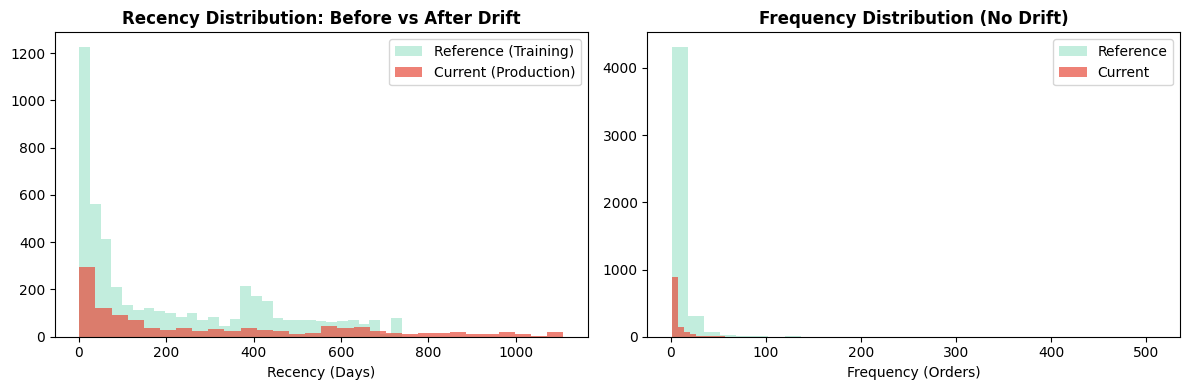

In [3]:
## Visualizing Drift

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(reference['Recency'], bins=30, alpha=0.7, color='#a8e6cf', label='Reference (Training)')
axes[0].hist(current['Recency'], bins=30, alpha=0.7, color='#e74c3c', label='Current (Production)')
axes[0].set_title('Recency Distribution: Before vs After Drift', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recency (Days)')
axes[0].legend()

axes[1].hist(reference['Frequency'], bins=30, alpha=0.7, color='#a8e6cf', label='Reference')
axes[1].hist(current['Frequency'], bins=30, alpha=0.7, color='#e74c3c', label='Current')
axes[1].set_title('Frequency Distribution (No Drift)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency (Orders)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Key Takeaways

- **Recency drift was detected**: A 50% increase signals customer behavior is changing in production.
- **Evidently AI monitors without manual checks** — automated drift detection should run on a schedule.
- **When drift exceeds thresholds, retrain**: Stale models make bad predictions.
- **Report ready for review**: Drift data saved as JSON for dashboard integration.